In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from numpy.polynomial.chebyshev import Chebyshev

In [2]:
years = np.array([i for i in range(1900,1981,10)])
population = np.array([76_212_168,92_228_496,106_021_496,123_202_624,132_164_569,151_325_798
                      ,179_323_175,203_302_031,226_542_199])

In [3]:
A = {}
results = {}
for i in range(7):
    coeffs = np.polyfit(years, population, i)
    y_fit = np.polyval(coeffs, 1990)
    A[i] = coeffs
    results[i] = y_fit


In [4]:
real_val = 248_709_873
err = {}
for i in range(7):
    err[i] = np.abs(results[i] - real_val) / np.abs(real_val)
print(err)

{0: 0.4235485260012619, 1: 0.051874746823756784, 2: 0.02413688027803375, 3: 0.05118206852878685, 4: 0.022527816665625495, 5: 0.11365375109173893, 6: 0.025604447958525556}


najmniejszy błąd względny dla stopnia 4 

### AIC

In [7]:
aic_scores = {}
for i in range(7):
    y_hat = np.polyval(A[i],years)
    rss = np.sum((population-y_hat)**2)
    n = len(population)
    k = i + 1
    aic = n * np.log(rss / n) + 2 * k
    aic_c = aic + (2*k * (k+1))/(n-k-1)
    aic_scores[i] = aic_c
print(aic_scores)

{0: 321.01097637083444, 1: 289.0564787925184, 2: 279.45335270711485, 3: 284.8803931355884, 4: 290.92859449227507, 5: 311.25823339868515, 6: 381.26647642791636}


Wartości nie pokrywają się


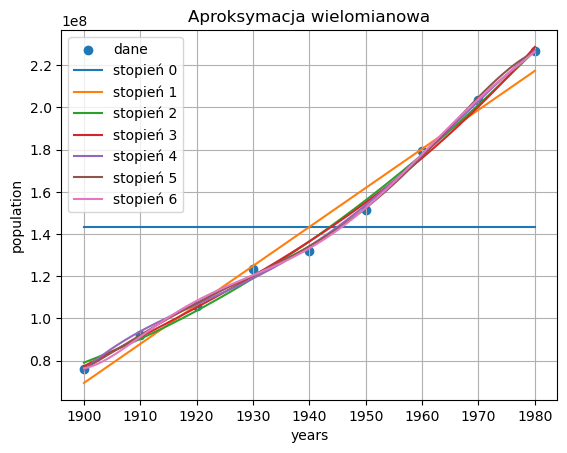

In [9]:
plt.scatter(years, population, label="dane")

x_dense = np.linspace(min(years), max(years), 300)

for i in range(7):
    y_dense = np.polyval(A[i], x_dense)
    plt.plot(x_dense, y_dense, label=f"stopień {i}")

plt.xlabel("years")
plt.ylabel("population")
plt.title("Aproksymacja wielomianowa")
plt.legend()
plt.grid(True)
plt.show()

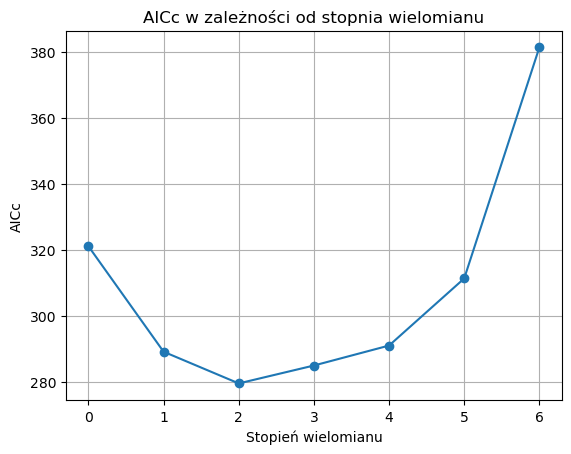

In [10]:
plt.plot(list(aic_scores.keys()), list(aic_scores.values()), marker='o')
plt.xlabel("Stopień wielomianu")
plt.ylabel("AICc")
plt.title("AICc w zależności od stopnia wielomianu")
plt.grid(True)
plt.show()

współczynniki Czebyszewa = [0.9003163161571008, 0.6002108774379304, -0.12004217548769343]
max błąd = 0.18006326323147703
średni błąd = 0.03149909132993246
RMSE = 0.036974081919775866


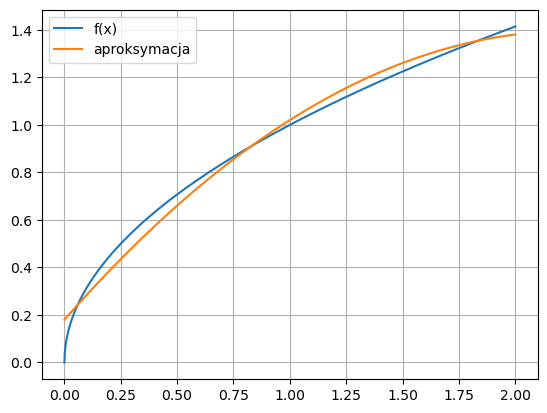

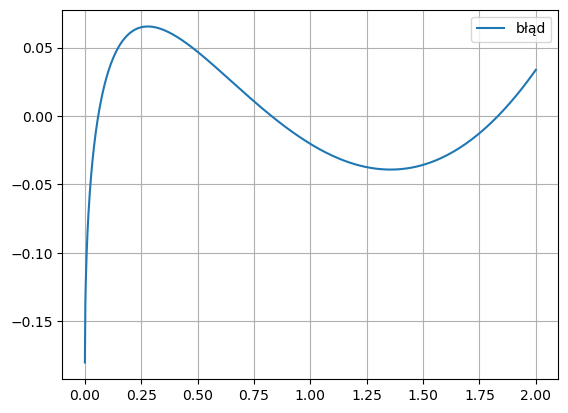

In [11]:
def f(x):
    return np.sqrt(x)

a, b = 0, 2
n = 2

def x_from_t(t):
    return (a + b) / 2 + (b - a) / 2 * t

def g(t):
    return f(x_from_t(t))

def integrand_base(t, k):
    Tk = Chebyshev.basis(k)
    return g(t) * Tk(t) / np.sqrt(1 - t**2)

def cheb_coeff(k):
    val, _ = quad(integrand_base, -1, 1, args=(k,))
    if k == 0:
        return val / np.pi
    return 2 * val / np.pi

coeffs = []
for k in range(n + 1):
    coeffs.append(cheb_coeff(k))

p = Chebyshev(coeffs)

def approx(x):
    t = (2*x - (a + b)) / (b - a)
    return p(t)

x = np.linspace(a, b, 1000)
y = f(x)
y_approx = approx(x)
err = y - y_approx

print("współczynniki Czebyszewa =", coeffs)
print("max błąd =", np.max(np.abs(err)))
print("średni błąd =", np.mean(np.abs(err)))
print("RMSE =", np.sqrt(np.mean(err**2)))

plt.plot(x, y, label="f(x)")
plt.plot(x, y_approx, label="aproksymacja")
plt.grid()
plt.legend()
plt.show()

plt.plot(x, err, label="błąd")
plt.grid()
plt.legend()
plt.show()